**Telecom Customer Churn & Customer Lifetime Value Analysis using SQL, Python and Power BI**

## Dataset

Telecom Customer Churn Dataset

Records: 7,032 customers

Target Variable: Churn Label

Tools Used:
- MySQL
- Python
- Power BI
- Scikit-learn
- Pandas
- Matplotlib
- Seaborn

                DATASET
                    │
                    ▼
        MySQL Business Analysis
                    │
                    ▼
      Python (EDA + Machine Learning)
                    │
                    ▼
        Power BI Dashboard
                    │
                    ▼
      Business Recommendations

# Project Overview

This project investigates customer churn behaviour and Customer Lifetime Value (CLTV) within a telecommunications company. MySQL is used for business analytics, Python for data cleaning, exploratory data analysis and machine learning, and Power BI for interactive dashboard development. The aim is to identify churn drivers, evaluate customer value, and provide actionable business recommendations.

The project combines:

- SQL for business analytics and KPI reporting
- Python for data cleaning, machine learning and statistical analysis
- Power BI for interactive dashboard development

Objectives:

- Identify key churn drivers
- Analyse customer lifetime value (CLTV)
- Predict customer churn using machine learning
- Provide actionable business recommendations

# SQL Business Analysis

The dataset was imported into MySQL to perform business-oriented SQL analysis. A series of aggregation, filtering, conditional, and ranking queries were used to identify customer churn patterns, evaluate customer lifetime value (CLTV), and uncover actionable business insights.

## Key Findings

1. Overall churn rate was 26.58%.

2. Month-to-month contracts showed the highest churn levels.

3. Fibre optic customers experienced significantly higher churn than DSL customers.

4. Electronic check customers showed the highest churn volume among payment methods.

5. Churned customers had higher average monthly charges (£74.44) compared to retained customers (£61.31).

6. Customers within their first 12 months of tenure experienced the highest churn rate (47.7%), indicating that early customer retention should be a business priority.

7. Average CLTV for churned customers (£4,149) was lower than retained customers (£4,493).

8. Major churn reasons included support experience, competitor pricing and competitor service offerings.

### SQL Techniques Used

The SQL analysis demonstrates the use of:

- Aggregate Functions (COUNT, AVG, SUM)
- Conditional Aggregation using CASE WHEN
- GROUP BY and ORDER BY
- Window Functions (RANK)
- Business KPI calculations
- Customer segmentation
- Churn rate calculations

# Power BI Dashboard

An interactive Power BI dashboard was developed to monitor customer churn performance and support business decision-making.

**Dashboard Features**

- Total customer KPI tracking
- Churn rate monitoring
- Contract type analysis
- Internet service analysis
- Payment method distribution
- Churn reason analysis
- Interactive filtering and drill-down capabilities

The interactive dashboard enables business stakeholders to monitor churn KPIs, identify high-risk customer segments, analyse customer behaviour, and support data-driven retention strategies.

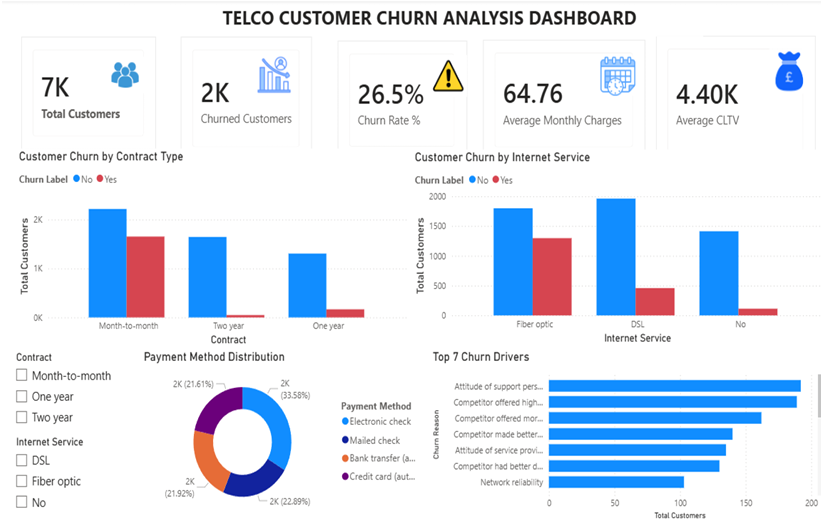

### Dashboard Insights

The dashboard provides an executive overview of customer churn performance.

Key observations include:

- Overall churn rate is 26.58%.
- Month-to-month contracts experience the highest customer churn.
- Fibre optic customers have significantly higher churn than DSL customers.
- Electronic check is the payment method associated with the highest churn.
- Competitor offers and customer service issues are the leading churn reasons.

These insights help identify high-risk customer segments and support targeted retention strategies.

## 1. Importing Required Libraries

In [3]:
# Import pandas library
import pandas as pd

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    r2_score
)

# Import statistical testing library
from scipy.stats import ttest_ind


## 2. Dataset Loading and Initial Exploration

The telecom customer churn dataset was imported into Python using pandas to analyse customer behaviour, subscription patterns, and churn-related variables.

In [4]:
# Load dataset directly from GitHub

dataset_url = "https://github.com/okayjatin/customer-churn-analysis/raw/refs/heads/main/Telco_customer_churn.xlsx"

df = pd.read_excel(dataset_url)

# Display first 5 rows
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Dataset Information

Dataset Name:
IBM Telecom Customer Churn Dataset

Original Source:
https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

Description:
This dataset contains demographic information, subscription details, billing information, contract types, churn status, and Customer Lifetime Value (CLTV) for 7,043 telecom customers. It is widely used for customer churn prediction, customer segmentation, and retention analysis.

GitHub Repository:
https://github.com/okayjatin/customer-churn-analysis

Dataset File:
https://github.com/okayjatin/customer-churn-analysis/raw/refs/heads/main/Telco_customer_churn.xlsx

## 3. Data Cleaning and Preprocessing

Initial preprocessing steps were conducted to identify missing values, examine data types, and prepare the dataset for machine learning analysis.

In [5]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
# Check dataset shape
df.shape

(7043, 33)

In [7]:
# Display column names
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


Missing values were checked to determine whether data imputation or cleaning was required before analysis.

In [8]:
# Check missing values
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


### Findings

The missing value analysis showed that all variables were complete except **Churn Reason**, which contained **5,174 missing values**.

These missing values are expected because the **Churn Reason** field is only applicable to customers who have churned. Customers who did not churn naturally have no associated churn reason, so these missing values were retained and treated as meaningful rather than data quality issues.

### Validating Categorical Variables

The unique values of key categorical variables were examined to verify data consistency and identify the categories available for analysis and machine learning.

In [9]:
# Check unique values in important categorical columns

print("Gender:", df['Gender'].unique())
print("\nContract:", df['Contract'].unique())
print("\nInternet Service:", df['Internet Service'].unique())
print("\nChurn Value:", df['Churn Value'].unique())

Gender: ['Male' 'Female']

Contract: ['Month-to-month' 'Two year' 'One year']

Internet Service: ['DSL' 'Fiber optic' 'No']

Churn Value: [1 0]


### Findings

The categorical variables contained valid and expected categories. No inconsistent or unexpected values were identified, confirming that these variables were suitable for further analysis.

### Feature Selection

A cleaned copy of the dataset was created for modelling. Variables that do not contribute to churn prediction, such as geographical identifiers, customer identifiers, and the churn reason, were removed to avoid information leakage and improve model performance.

In [10]:
# Create a cleaned copy of the dataset
df_clean = df.copy()

# Create a modelling dataset by removing non-predictive columns
df_clean = df_clean.drop(columns=[
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Reason'
])

# Display first 5 rows of cleaned dataset
df_clean.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340


## 4. Encoding Categorical Variables

Categorical variables were converted into numerical representations using Label Encoding. This transformation allows machine learning algorithms to process categorical information while preserving all observations in the dataset.

### Encoding Process

Machine learning algorithms require numerical inputs. Therefore, all categorical variables in the cleaned dataset were identified automatically and converted into numeric labels using Scikit-learn's LabelEncoder.

In [11]:
# Initialise Label Encoder
label_encoder = LabelEncoder()

# Identify all categorical variables
categorical_columns = df_clean.select_dtypes(include=['object']).columns

# Ensure consistent string datatype before encoding
for column in categorical_columns:
    df_clean[column] = df_clean[column].astype(str)

# Apply Label Encoding to each categorical feature
for column in categorical_columns:
    df_clean[column] = label_encoder.fit_transform(df_clean[column])

# Preview encoded dataset
df_clean.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,1,0,0,0,2,1,0,0,2,2,...,0,0,1,3,53.85,157,1,1,86,3239
1,0,0,0,1,2,1,0,1,0,0,...,0,0,1,2,70.70,925,1,1,67,2701
2,0,0,0,1,8,1,2,1,0,0,...,2,0,1,2,99.65,6104,1,1,86,5372
3,0,0,1,1,28,1,2,1,0,0,...,2,0,1,2,104.80,2646,1,1,84,5003
4,1,0,0,1,49,1,2,1,0,2,...,2,0,1,0,103.70,4265,1,1,89,5340


### Findings

All categorical variables were successfully encoded into numerical values without data loss. The dataset is now fully numerical and suitable for exploratory analysis and machine learning model development.

## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was conducted to understand customer behaviour, identify churn patterns, explore relationships between key variables, and uncover business insights prior to predictive modelling.

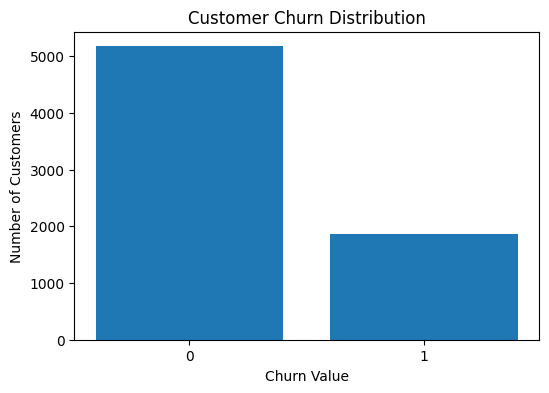

In [12]:
# Count churn values
churn_counts = df['Churn Value'].value_counts()

# Create bar chart
plt.figure(figsize=(6,4))
plt.bar(churn_counts.index.astype(str), churn_counts.values)

# Add labels and title
plt.xlabel('Churn Value')
plt.ylabel('Number of Customers')
plt.title('Customer Churn Distribution')

# Show chart
plt.show()

### Interpretation


The dataset is moderately imbalanced, with a substantially larger number of retained customers than churned customers.

Approximately **26.5%** of customers discontinued their subscriptions, while **73.5%** remained active. Although customer retention is relatively high, the churn rate is still significant enough to justify further investigation into the factors influencing customer attrition.

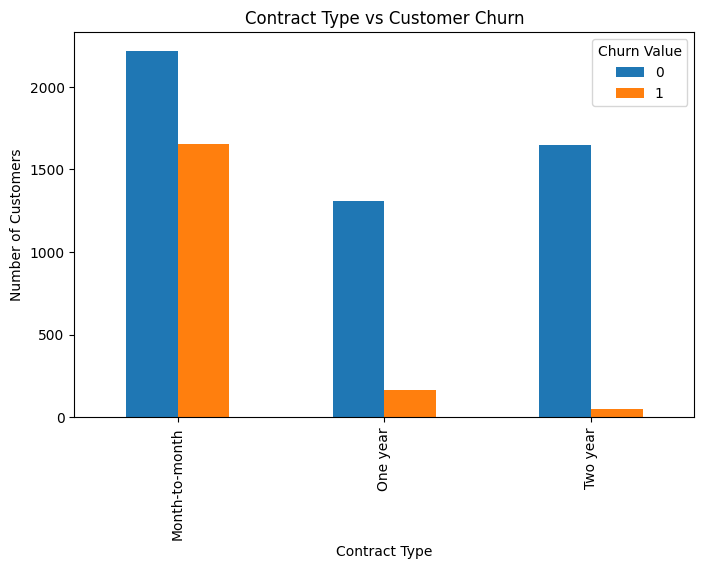

In [13]:
# Create contract type vs churn chart
contract_churn = pd.crosstab(df['Contract'], df['Churn Value'])

# Plot chart
contract_churn.plot(kind='bar', figsize=(8,5))

# Add labels and title
plt.title('Contract Type vs Customer Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

# Show chart
plt.show()

### Interpretation

Customers with **month-to-month contracts** experienced the highest level of churn compared with customers on one-year and two-year contracts.

Longer contract commitments appear to improve customer retention, suggesting that contract duration plays a significant role in reducing churn risk.

<Figure size 800x500 with 0 Axes>

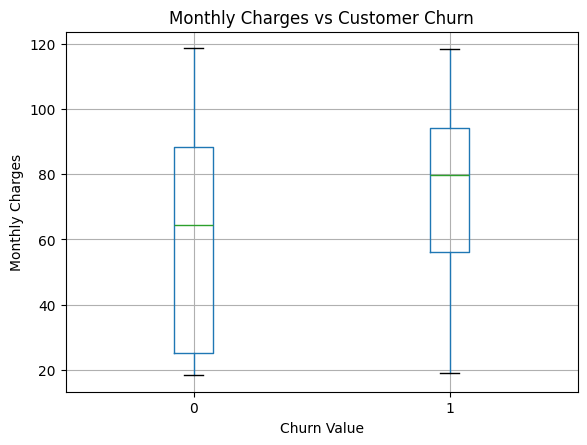

In [14]:
# Create boxplot for monthly charges vs churn
plt.figure(figsize=(8,5))

df.boxplot(column='Monthly Charges', by='Churn Value')

# Add title and labels
plt.title('Monthly Charges vs Customer Churn')
plt.suptitle('')
plt.xlabel('Churn Value')
plt.ylabel('Monthly Charges')

# Show chart
plt.show()

### Interpretation

The boxplot shows that customers who churned generally paid higher monthly charges than retained customers. The median monthly charge for churned customers is noticeably higher, indicating that pricing may influence customer retention.

This finding aligns with the earlier SQL analysis, where churned customers recorded an average monthly charge of **£74.44** compared with **£61.31** for retained customers.

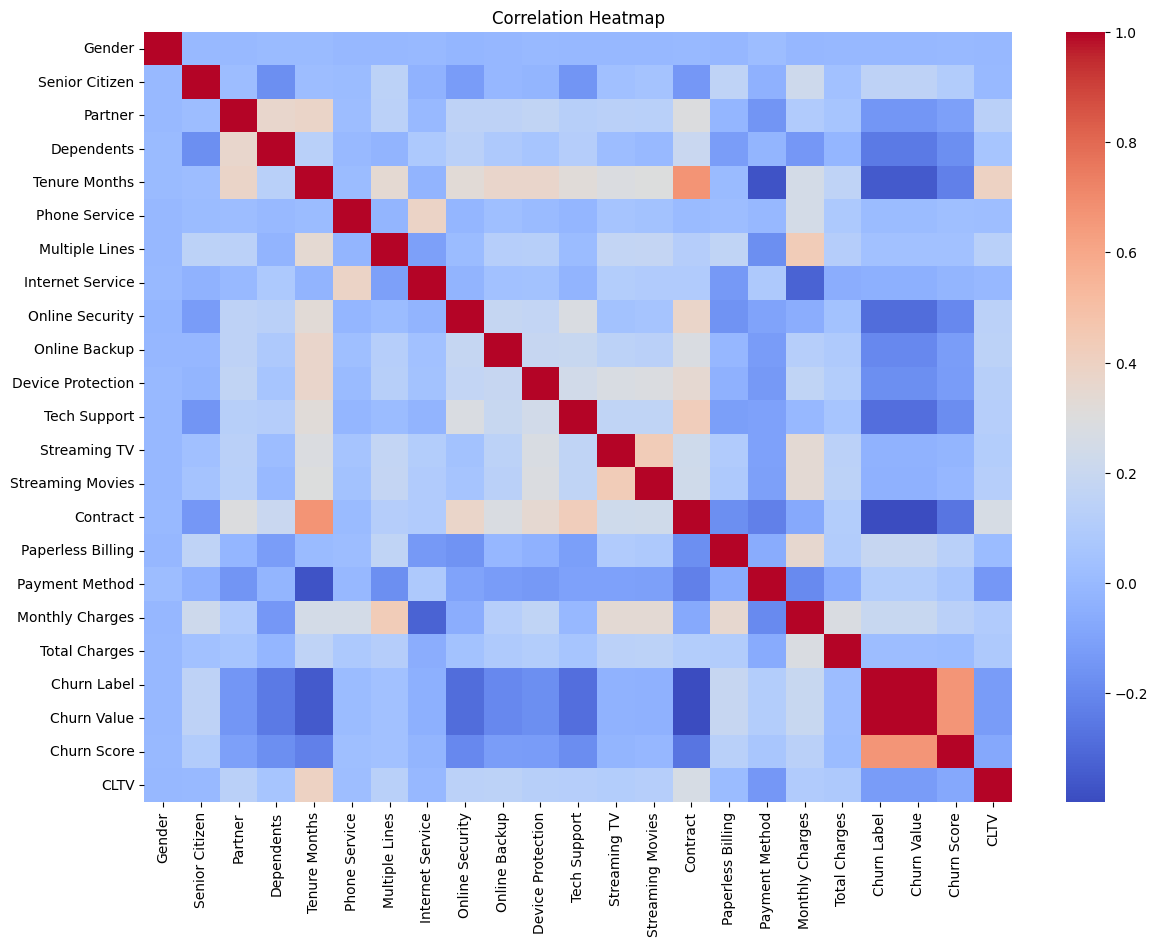

In [15]:
# Create correlation matrix
correlation_matrix = df_clean.corr()

# Create heatmap
plt.figure(figsize=(14,10))

sns.heatmap(correlation_matrix, cmap='coolwarm')

# Add title
plt.title('Correlation Heatmap')

# Show chart
plt.show()

### Interpretation

The correlation matrix highlights several important relationships within the dataset. Customer churn is positively associated with higher monthly charges and month-to-month contracts, while longer tenure and higher customer lifetime value (CLTV) show negative relationships with churn.

These patterns support the earlier SQL findings and provide evidence for selecting these variables during predictive modelling.

In [16]:
# Define feature variables (X)
X = df_clean.drop('Churn Value', axis=1)

# Define target variable (y)
y = df_clean['Churn Value']

# Display shapes
print("Feature Dataset Shape:", X.shape)
print("Target Dataset Shape:", y.shape)

Feature Dataset Shape: (7043, 22)
Target Dataset Shape: (7043,)


In [17]:
X = df_clean.drop(columns=[
    'Churn Value',
    'Churn Label',
    'Churn Score',
    'CLTV'
])

# Target variable
y = df_clean['Churn Value']

# Display shapes
print("Updated X shape:", X.shape)
print("Updated y shape:", y.shape)

Updated X shape: (7043, 19)
Updated y shape: (7043,)


## 6. Classification Analysis: Customer Churn Prediction

A Decision Tree Classification model was developed to predict customer churn behaviour using telecom customer subscription data.

In [18]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 19)
X_test shape: (1409, 19)
y_train shape: (5634,)
y_test shape: (1409,)


In [19]:
# Create classification model
classifier = DecisionTreeClassifier(random_state=42)

# Train the model
classifier.fit(X_train, y_train)

# Predict churn values
y_pred = classifier.predict(X_test)

# Display first 10 predictions
print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[1 0 0 1 0 1 1 1 1 0]


### Model Prediction

The Decision Tree model generated churn predictions based on customer subscription behaviour and service-related characteristics.

In [20]:
# Calculate classification accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display accuracy
print("Updated Model Accuracy:", accuracy)

Updated Model Accuracy: 0.7345635202271115


### Classification Model Performance

The Decision Tree Classification model achieved moderate predictive performance in identifying customer churn behaviour within telecom subscription services. The model demonstrated realistic predictive capability after removing leakage-related variables from the dataset.

In [21]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
print(cm)

[[810 199]
 [175 225]]


### Confusion Matrix Interpretation

The confusion matrix demonstrated that the model correctly identified a large proportion of retained customers and a moderate proportion of churned customers. Some churn behaviour remained difficult to predict due to complex customer decision-making patterns.

In [22]:
# Generate classification report
report = classification_report(y_test, y_pred)

# Display report
print(report)

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1009
           1       0.53      0.56      0.55       400

    accuracy                           0.73      1409
   macro avg       0.68      0.68      0.68      1409
weighted avg       0.74      0.73      0.74      1409



### Classification Report Interpretation

The classification report demonstrated stronger predictive performance for retained customers compared to churned customers. Lower recall for churned customers suggests that some customer attrition behaviour remains difficult to predict accurately due to complex behavioural factors.

### Feature Importance Analysis

Feature importance analysis was performed to identify the variables that contributed most strongly to customer churn prediction within the Decision Tree model.

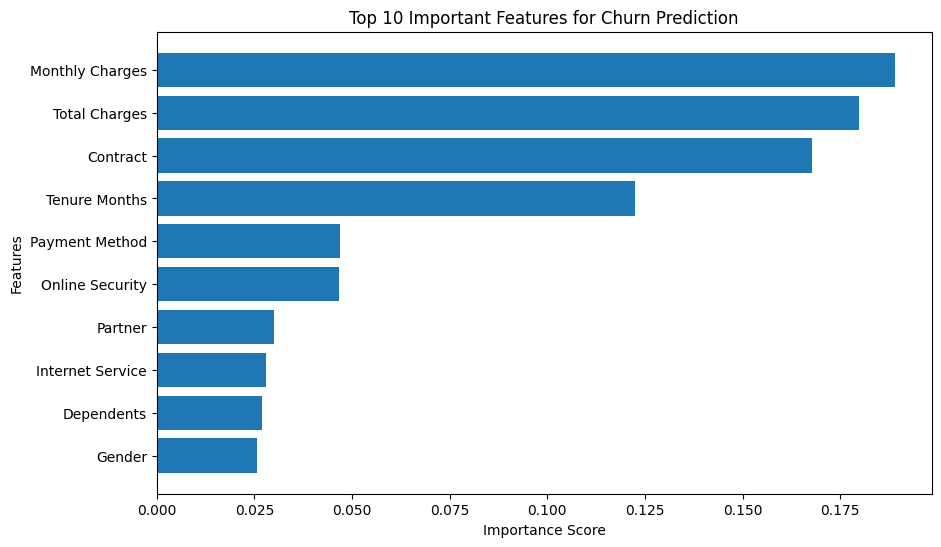

In [23]:
# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': classifier.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 10 features
top_features = feature_importance.head(10)

# Plot feature importance
plt.figure(figsize=(10,6))

plt.barh(top_features['Feature'], top_features['Importance'])

# Add labels and title
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Important Features for Churn Prediction')

# Reverse order for better readability
plt.gca().invert_yaxis()

# Show chart
plt.show()

### Feature Importance Interpretation

Monthly charges, total charges, contract type, and tenure months were identified as the most influential variables affecting customer churn prediction. These findings highlight the importance of pricing strategy, customer retention initiatives, and long-term contractual engagement within telecom subscription services.

## 7. Regression Analysis: Customer Lifetime Value Prediction

In [24]:
# Define regression features
X_reg = df_clean.drop(columns=['CLTV'])

# Define regression target
y_reg = df_clean['CLTV']

# Display shapes
print("Regression Features Shape:", X_reg.shape)
print("Regression Target Shape:", y_reg.shape)

Regression Features Shape: (7043, 22)
Regression Target Shape: (7043,)


In [25]:
# Split regression dataset
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Create Linear Regression model
regressor = LinearRegression()

# Train model
regressor.fit(X_train_reg, y_train_reg)

# Predict CLTV values
y_pred_reg = regressor.predict(X_test_reg)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

# Display results
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 896.0527456271307
R2 Score: 0.16930611479889868


### Regression Model Interpretation

The Linear Regression model achieved a Mean Absolute Error (MAE) of approximately 896 and an R² score of 0.169. The relatively low R² value indicates that the available customer variables explained only a limited proportion of the variation in Customer Lifetime Value (CLTV). This suggests that customer profitability is influenced by additional behavioural and financial factors not captured within the dataset. Nevertheless, the model provides useful insights into customer value trends and demonstrates the application of predictive analytics for profitability assessment.

## 8. Hypothesis Testing

An independent t-test was conducted to determine whether monthly charges significantly differed between churned and retained customers.

In [26]:
# Import t-test library
from scipy.stats import ttest_ind

# Monthly charges for retained customers
stay_customers = df[df['Churn Value'] == 0]['Monthly Charges']

# Monthly charges for churned customers
churn_customers = df[df['Churn Value'] == 1]['Monthly Charges']

# Perform independent t-test
t_stat, p_value = ttest_ind(stay_customers, churn_customers)

# Display results
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -16.536738015936308
P-Value: 2.7066456068884154e-60


### Hypothesis Testing Interpretation

The independent t-test produced a p-value significantly below the 0.05 significance threshold. Therefore, the null hypothesis was rejected, indicating a statistically significant difference in monthly charges between churned and retained customers. The findings suggest that pricing plays an important role in influencing customer churn behaviour within telecom subscription services.

## 9. Business Recommendations

Based on the findings of the analysis, the following recommendations are proposed for telecom service providers:

- Encourage customers to transition from month-to-month contracts to longer-term agreements through discounts and loyalty incentives.
- Identify customers with high monthly charges and short tenure periods for targeted retention campaigns.
- Promote value-added services such as online security, technical support, and bundled service packages to increase customer engagement.
- Use predictive analytics models to identify high-risk customers and implement proactive retention strategies.
- Monitor Customer Lifetime Value (CLTV) trends to prioritise retention efforts towards high-value customers.

## 10. Conclusion

The analysis demonstrated that customer churn within telecom subscription services is influenced by several factors, including contract type, monthly charges, tenure, and service-related characteristics. The Decision Tree Classification model achieved moderate predictive performance, while the Linear Regression model provided insight into Customer Lifetime Value trends. Statistical testing further confirmed the significance of pricing differences between churned and retained customers. These findings highlight opportunities for telecom providers to improve retention strategies, optimise pricing structures, and enhance long-term customer profitability.

## References

Yeanzc. (2020). Telco Customer Churn: IBM Dataset. Kaggle.
https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

Pandas Development Team. Pandas Documentation.
https://pandas.pydata.org/

Scikit-learn Developers. Scikit-learn Documentation.
https://scikit-learn.org/stable/

Hunter, J. D. Matplotlib Documentation.
https://matplotlib.org/

Waskom, M. Seaborn Documentation.
https://seaborn.pydata.org/